In [51]:
# Import libraries 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

# Print version of each library
print(pd.__version__)
#print(plt.__version__)
print(sns.__version__)
print(np.__version__)

3.0.0
0.13.2
2.3.2


# Data Loading

In [52]:
# Load the Dataset
df = pd.read_csv("../Datasets/Housing.csv")

In [53]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Data Splitting

In [54]:
# Spit dataset
from sklearn.model_selection import train_test_split

In [55]:
X = df.drop('price', axis = 1) # Features
y = df['price'] # Target

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [57]:
print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (381, 12)
X_test Shape: (164, 12)
Y_train Shape: (381,)
Y_test Shape: (164,)


# Preprocessing

In [58]:
# Identify numerical and categoricla features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features)

categorical_features = X_train.select_dtypes(include=['str']).columns
print("Categorical Features:", categorical_features)

Numeric Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')
Categorical Features: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [59]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


numeric_preprocess = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_preprocess = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('nums', numeric_preprocess, numeric_features ),
        ('cat', categorical_preprocess, categorical_features)
    ]
)

# Model — Decision Tree

In [60]:
# Decision Tree initialization
from sklearn.tree import DecisionTreeRegressor

you might see BaseDecisionTree as a internal parent classs of the sklearn library, but you will need to use DecisionTree Regresssor for the user friednly implementation

In [61]:
from sklearn.pipeline import Pipeline

Dtree_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', DecisionTreeRegressor(max_depth=4, random_state=1))    
])

In [62]:
Dtree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regression model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [63]:
# Get fitted objects from the pipeline
tree_model = Dtree_pipeline.named_steps['regression model']
preprocessor = Dtree_pipeline.named_steps['preprocessor']

In [64]:
# .predict(X_test) applies the train model to unseedn test features
# Pipeline transfomrs X_test into the same scaler encoder as the fitter X_train
# The model outputs a predicted price for each row in X_test
y_Dtree_pred = Dtree_pipeline.predict(X_test)

In [65]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_Dtree_pred[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [6772957, 5261520, 7896000, 5676222, 3936210, 3625273, 3230145, 5261520, 3625273, 4457119]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


In [66]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = Dtree_pipeline.predict(new_house)
print(predicted_price)

[5486468.75]


# Evaluation

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# We define a function to reuse the model evaluation
def evaluate_model(y_true, y_pred, model_name="Model"):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"R-squared:              {r2:.4f}")
    print(f"Mean Squared Error:     {mse:.4f}")
    print(f"Root Mean Sq Error:     {np.sqrt(mse):.4f}")
    print(f"Mean Absolute Error:    {mae:.4f}")
    print()

In [68]:
evaluate_model(y_test, y_Dtree_pred, "Decision Tree")

--- Decision Tree ---
R-squared:              0.4817
Mean Squared Error:     2109716663891.3376
Root Mean Sq Error:     1452486.3730
Mean Absolute Error:    1045662.6379



In [69]:
y_pred_Dtree_train = Dtree_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_Dtree_train, "Decision Tree (Train)")

--- Decision Tree (Train) ---
R-squared:              0.6306
Mean Squared Error:     1197892702162.7192
Root Mean Sq Error:     1094482.8469
Mean Absolute Error:    803524.5741



# Visualizations

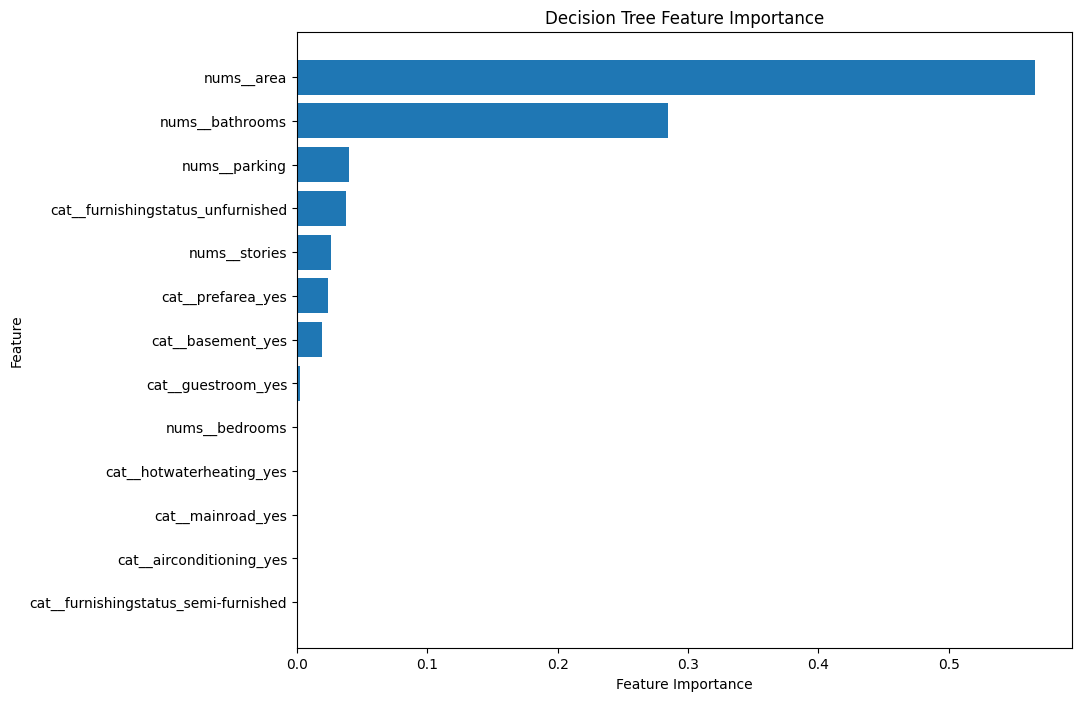

,Feature,Importance
0,nums__area,0.566050
2,nums__bathrooms,0.284564
4,nums__parking,0.040000
12,cat__furnishingstatus_unfurnished,0.037791
3,nums__stories,0.025794
10,cat__prefarea_yes,0.023731
7,cat__basement_yes,0.019425
6,cat__guestroom_yes,0.002646
1,nums__bedrooms,0.000000
8,cat__hotwaterheating_yes,0.000000


In [70]:
# Visualize feature importante
# Get transformed feature names after scaling + one hot encoding
feature_names = preprocessor.get_feature_names_out()

# Build feature importance table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Optional: display the table
feature_importance_df.head(15)

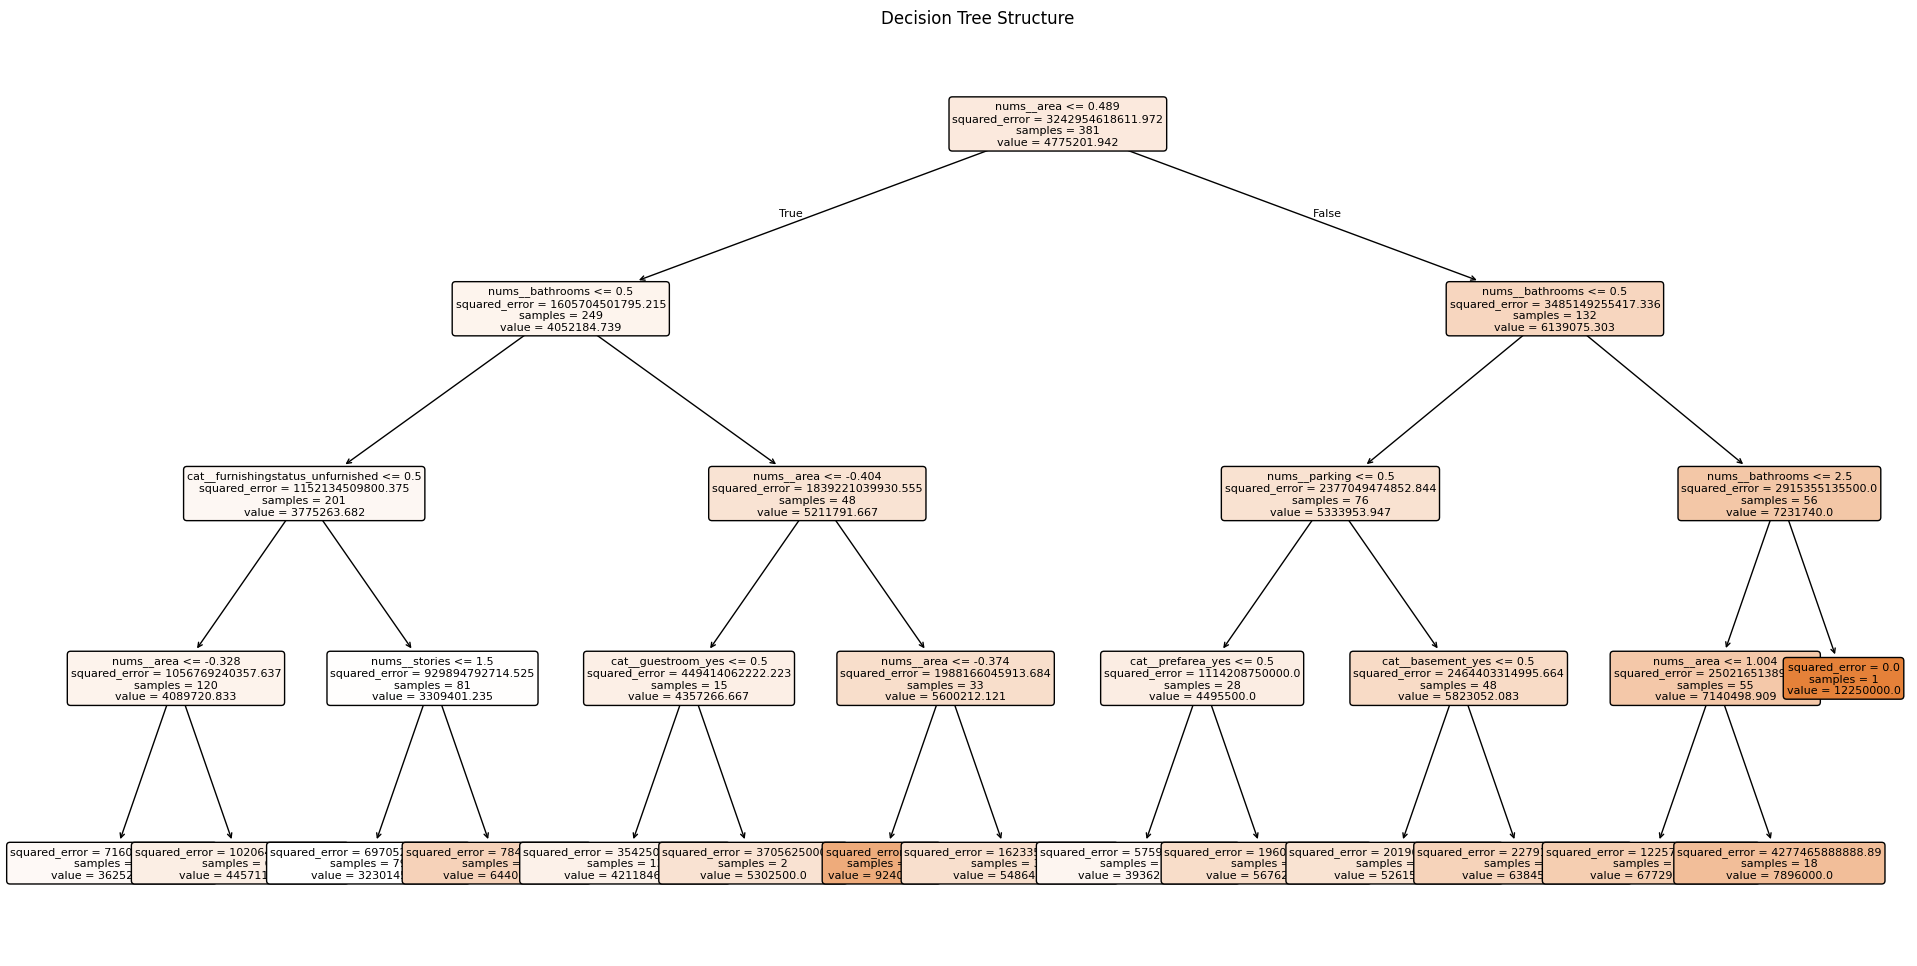

In [71]:
from sklearn.tree import plot_tree

tree_model = Dtree_pipeline.named_steps['regression model']
feature_names = Dtree_pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

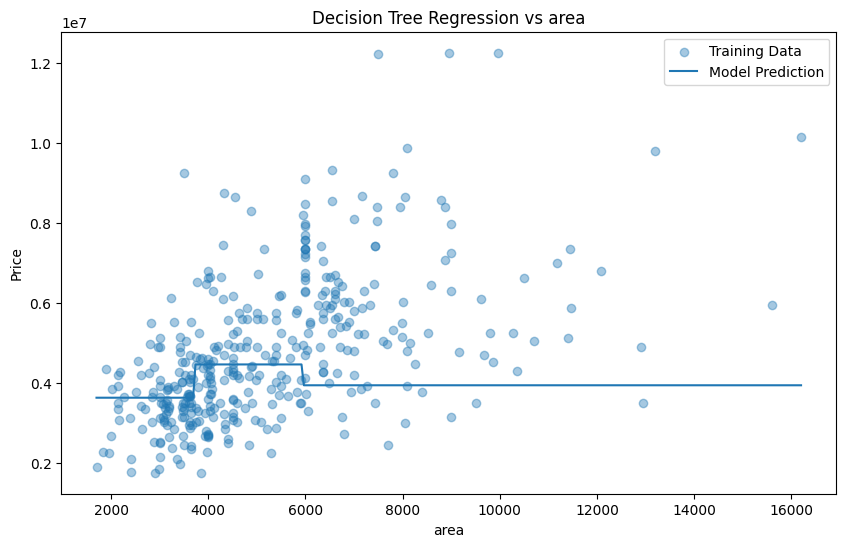

In [72]:
feature_to_vary = 'area'

# Create a baseline row using median for numeric and mode for categorical
baseline = X_train.copy()

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

# Create grid over the chosen feature
x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)

X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

# Predict
y_grid_pred = Dtree_pipeline.predict(X_grid)


plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"Decision Tree Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

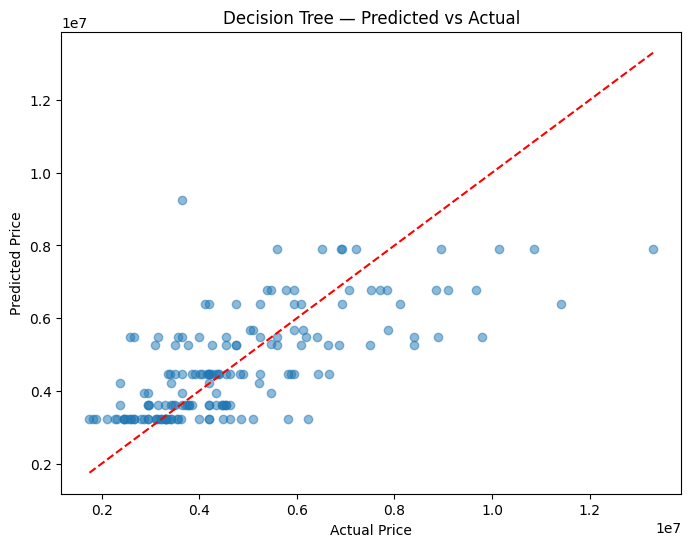

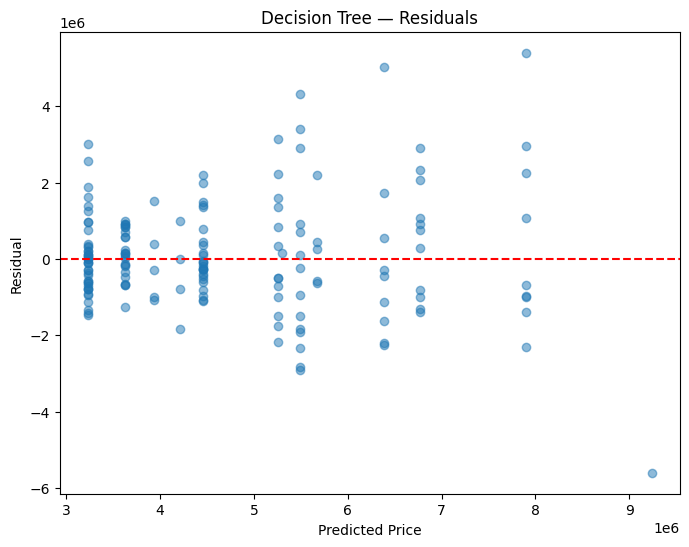

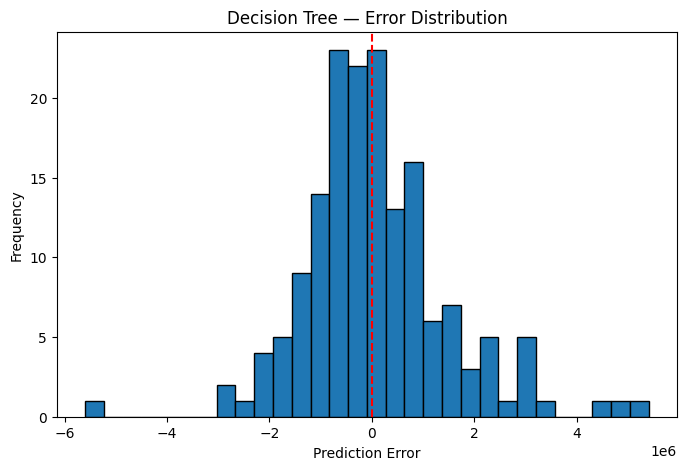

In [73]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_Dtree_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree — Predicted vs Actual")
plt.show()

# Residual plot
residuals_dt = y_test - y_Dtree_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_Dtree_pred, residuals_dt, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Decision Tree — Residuals")
plt.show()

# Error distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals_dt, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Decision Tree — Error Distribution")
plt.show()

# Model — Random Forest

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
RForest_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', RandomForestRegressor(n_estimators=100, random_state=1, max_depth=4))
])

In [76]:
RForest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regression model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [77]:
# Get fitted objects from the pipeline
RandomForest_model = RForest_pipeline.named_steps['regression model']
preprocessor = RForest_pipeline.named_steps['preprocessor']

In [78]:
y_pred_RForest = RForest_pipeline.predict(X_test)

In [79]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_RForest[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [7017346, 5476501, 7960631, 5713020, 4462528, 3736706, 3115974, 5826031, 3390579, 4301738]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


In [80]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = RForest_pipeline.predict(new_house)
print(predicted_price)

[5696377.89413473]


# Evaluation

In [81]:
evaluate_model(y_test, y_pred_RForest, "Random Forest")

--- Random Forest ---
R-squared:              0.6090
Mean Squared Error:     1591517284492.6213
Root Mean Sq Error:     1261553.5203
Mean Absolute Error:    913846.0420



In [82]:
y_pred_train = RForest_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_train, "Random Forest (Train)")

--- Random Forest (Train) ---
R-squared:              0.7057
Mean Squared Error:     954349353898.0228
Root Mean Sq Error:     976908.0581
Mean Absolute Error:    731567.5578



# Visualization

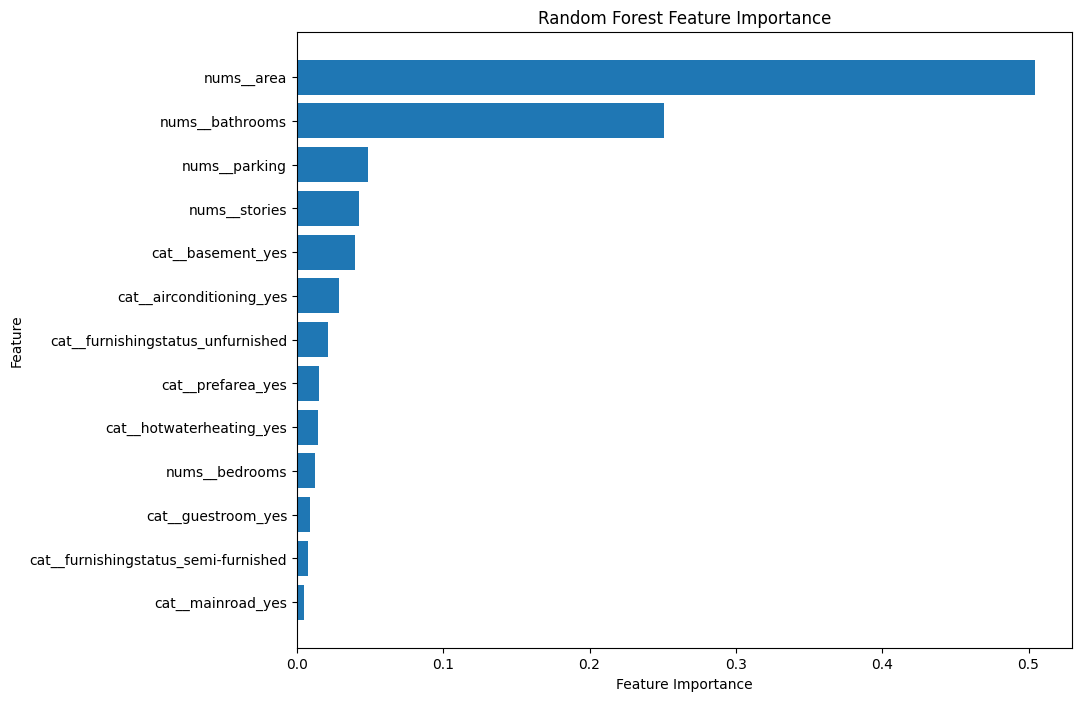

,Feature,Importance
0,nums__area,0.504427
2,nums__bathrooms,0.251024
4,nums__parking,0.048698
3,nums__stories,0.042733
7,cat__basement_yes,0.039471
9,cat__airconditioning_yes,0.028765
12,cat__furnishingstatus_unfurnished,0.021100
10,cat__prefarea_yes,0.015094
8,cat__hotwaterheating_yes,0.014729
1,nums__bedrooms,0.012266


In [83]:
# Visualize feature importante
# Get transformed feature names after scaling + one hot encoding
feature_names = preprocessor.get_feature_names_out()

# Build feature importance table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': RandomForest_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Optional: display the table
feature_importance_df.head(15)

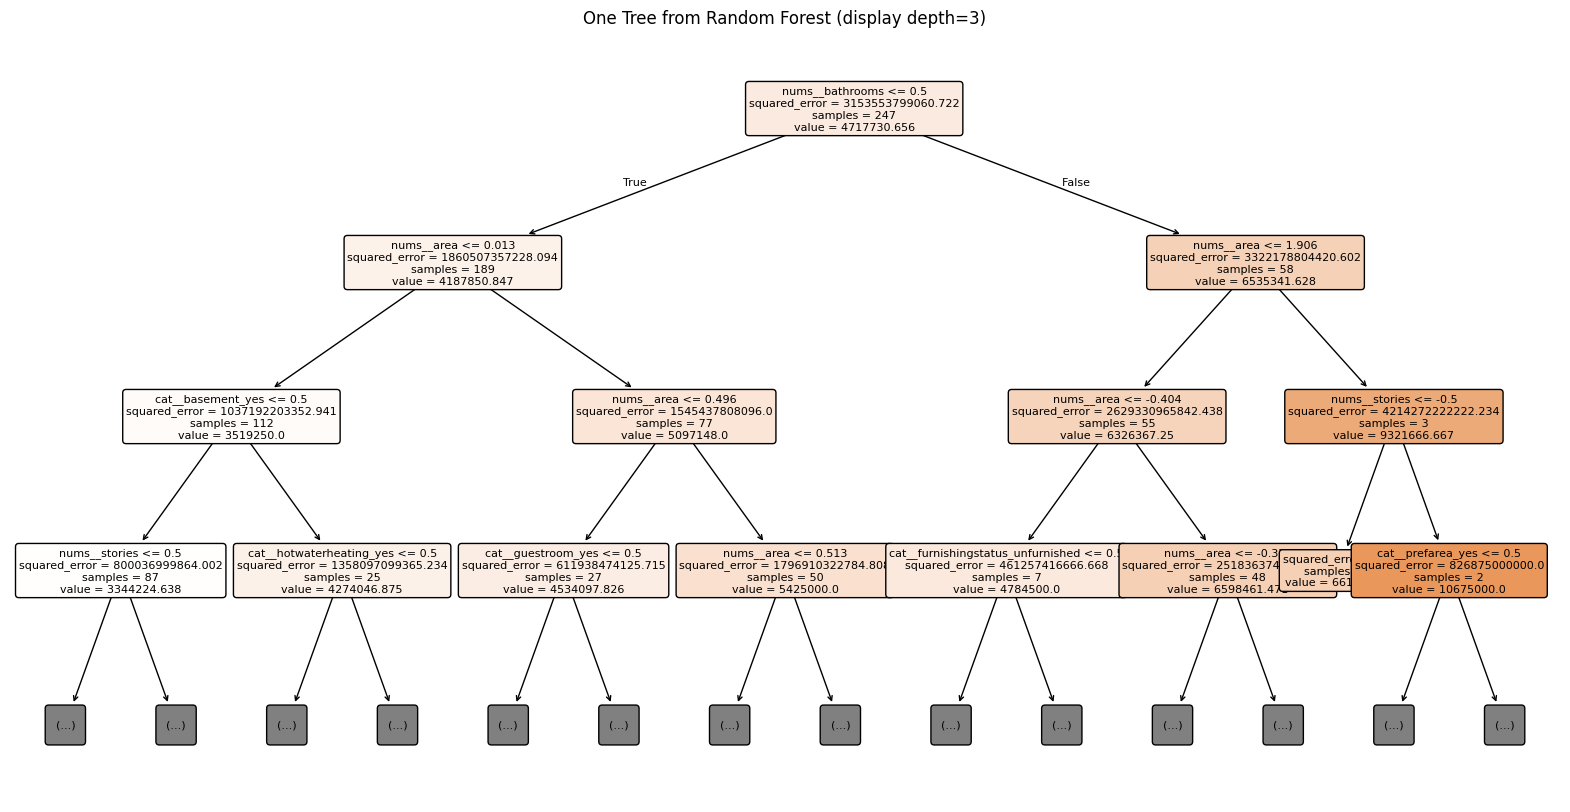

In [84]:
from sklearn.tree import plot_tree

feature_names = RForest_pipeline.named_steps['preprocessor'].get_feature_names_out()
tree_to_plot = RandomForest_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_to_plot,
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("One Tree from Random Forest (display depth=3)")
plt.show()

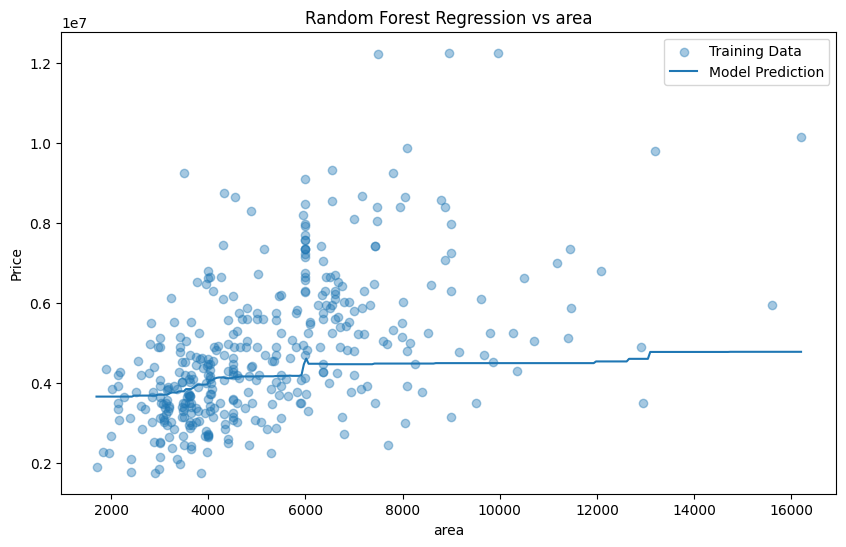

In [85]:
feature_to_vary = 'area'

# Create a baseline row using median for numeric and mode for categorical
baseline = X_train.copy()

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

# Create grid over the chosen feature
x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)

X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

# Predict
y_grid_pred = RForest_pipeline.predict(X_grid)


plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"Random Forest Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

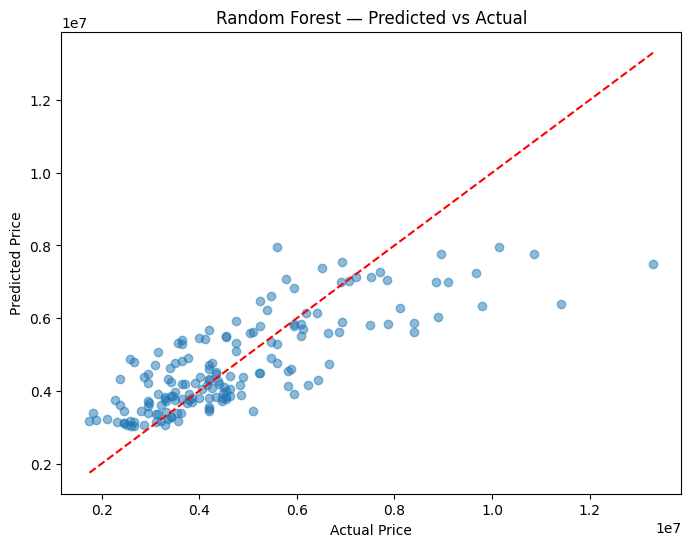

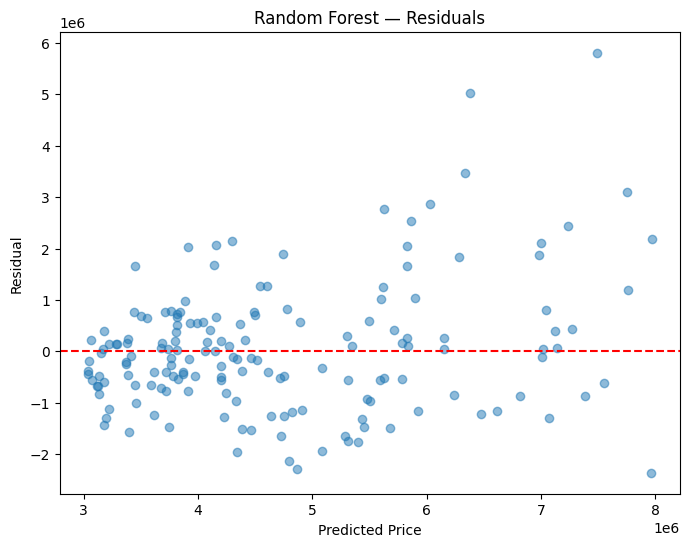

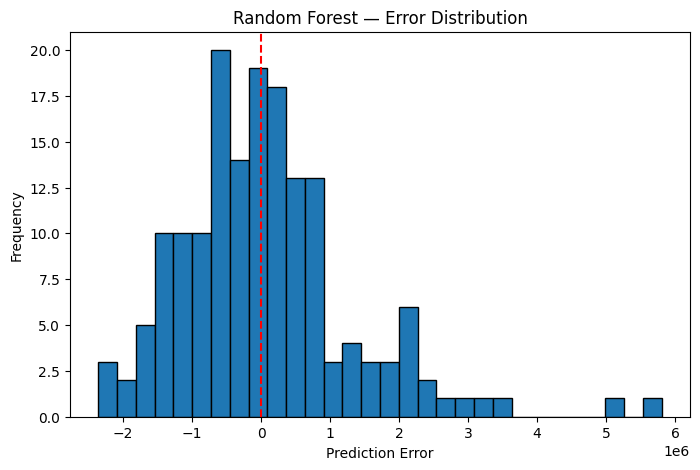

In [86]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_RForest, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest — Predicted vs Actual")
plt.show()

# Residual plot
residuals_rf = y_test - y_pred_RForest
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_RForest, residuals_rf, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Random Forest — Residuals")
plt.show()

# Error distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals_rf, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Random Forest — Error Distribution")
plt.show()

# Model — XGBoost

In [87]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('regression model', XGBRegressor(n_estimators=100, random_state=1))
])

xgb_pipeline.fit(X_train, y_train)

XGB_model = xgb_pipeline.named_steps['regression model']
y_pred_XGB = xgb_pipeline.predict(X_test)

print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_XGB[:10]])
print('Real prices: \n', [int(i) for i in y_test[:10]])

First 10:
Predicted prices: 
 [7321867, 4649878, 8428628, 6808605, 4412892, 3602966, 2835225, 5622904, 3053494, 4453269]
Real prices: 
 [7070000, 4550000, 5600000, 6125000, 2940000, 3780000, 2450000, 7490000, 2940000, 6440000]


In [88]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes', 'parking': 1,
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

predicted_price = xgb_pipeline.predict(new_house)
print(predicted_price)

[6.5233095e+06]


# Evaluation

In [89]:
evaluate_model(y_test, y_pred_XGB, "XGBoost")

y_pred_XGB_train = xgb_pipeline.predict(X_train)
evaluate_model(y_train, y_pred_XGB_train, "XGBoost (Train)")

--- XGBoost ---
R-squared:              0.5803
Mean Squared Error:     1708335824896.0000
Root Mean Sq Error:     1307033.2149
Mean Absolute Error:    951679.0000

--- XGBoost (Train) ---
R-squared:              0.9989
Mean Squared Error:     3417304320.0000
Root Mean Sq Error:     58457.7139
Mean Absolute Error:    39384.1797



# Visualizations

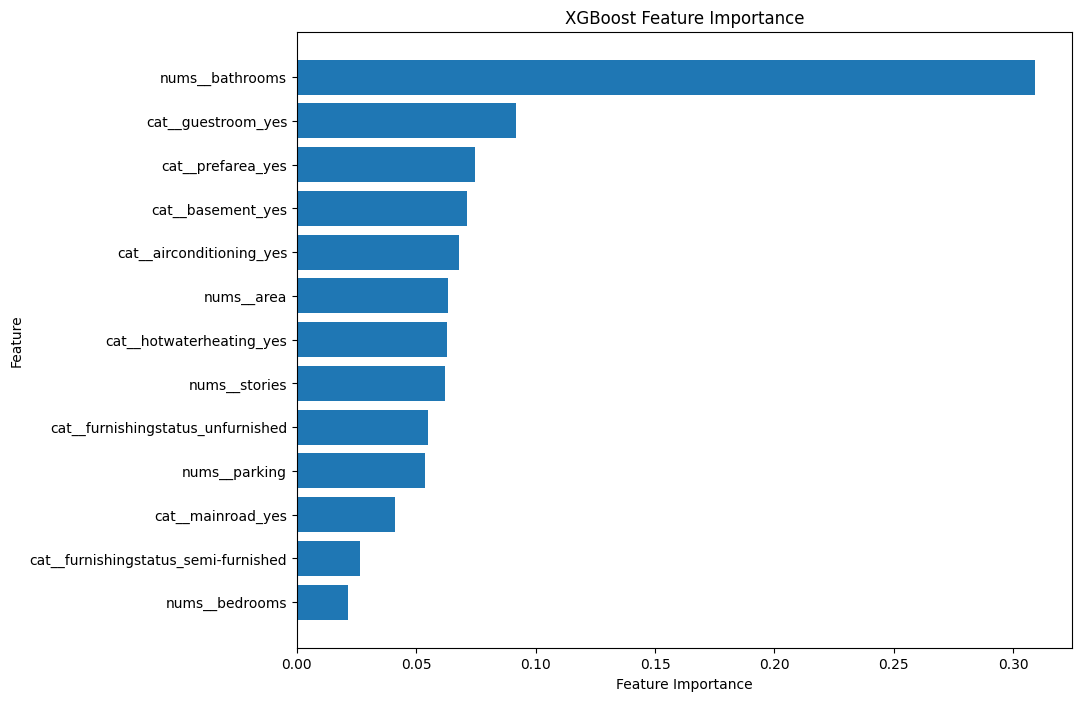

,Feature,Importance
2,nums__bathrooms,0.309127
6,cat__guestroom_yes,0.091698
10,cat__prefarea_yes,0.074624
7,cat__basement_yes,0.071085
9,cat__airconditioning_yes,0.067719
0,nums__area,0.063184
8,cat__hotwaterheating_yes,0.062814
3,nums__stories,0.062230
12,cat__furnishingstatus_unfurnished,0.055084
4,nums__parking,0.053685


In [90]:
# Feature Importance
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': XGB_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

feature_importance_df.head(15)

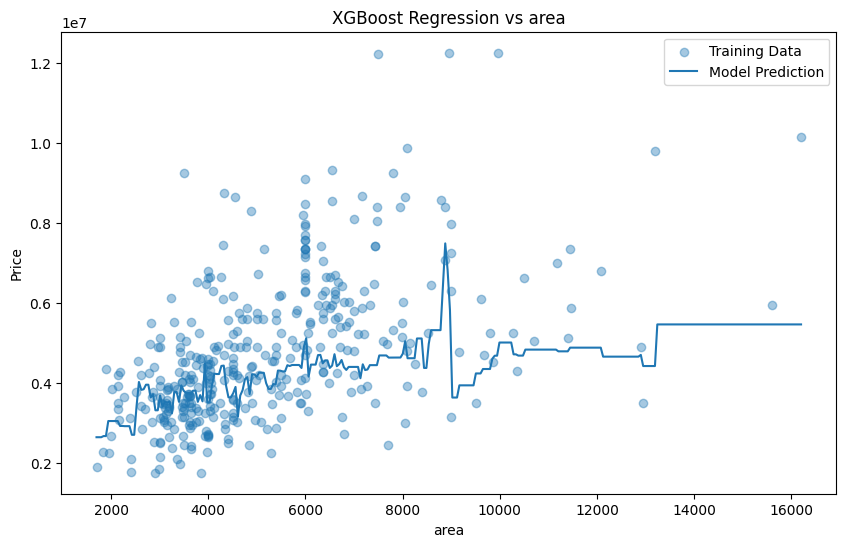

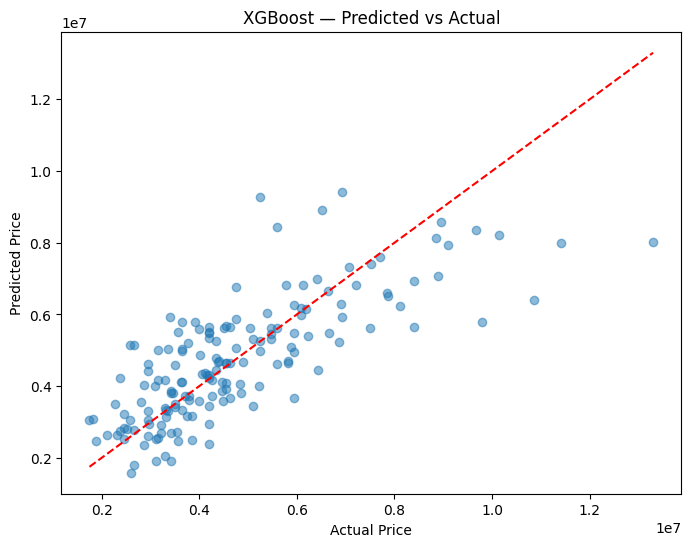

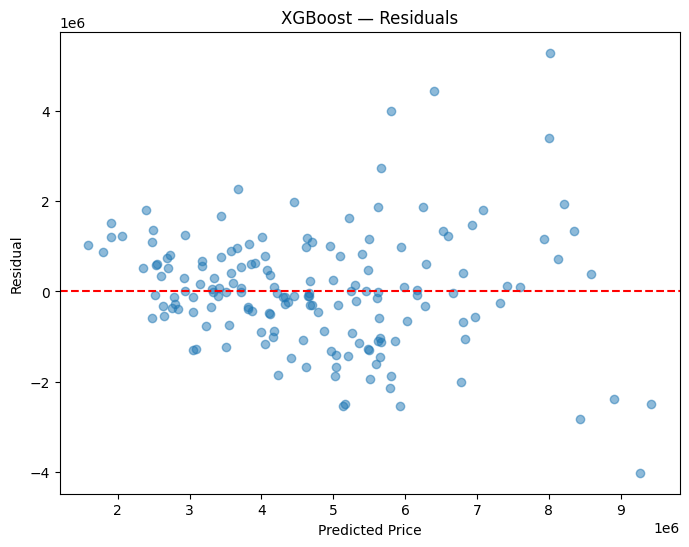

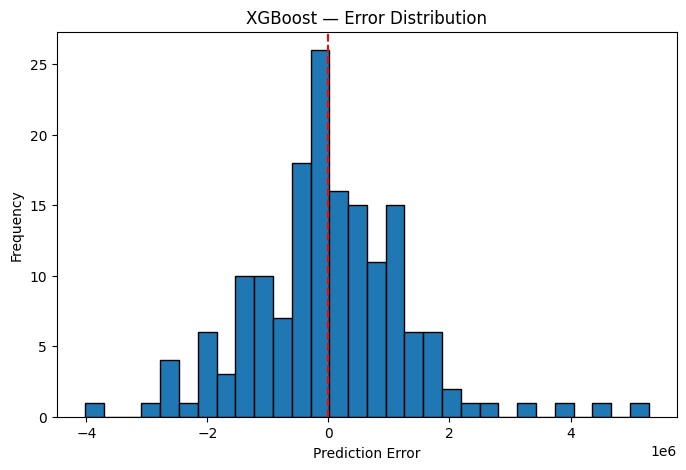

In [91]:
# Scatter vs area
feature_to_vary = 'area'

base_row = {}
for col in X_train.columns:
    if col in numeric_features:
        base_row[col] = X_train[col].median()
    else:
        base_row[col] = X_train[col].mode()[0]

x_vals = np.linspace(X_train[feature_to_vary].min(), X_train[feature_to_vary].max(), 300)
X_grid = pd.DataFrame([base_row] * len(x_vals))
X_grid[feature_to_vary] = x_vals

y_grid_pred = xgb_pipeline.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X_train[feature_to_vary], y_train, alpha=0.4, label='Training Data')
plt.plot(x_vals, y_grid_pred, label='Model Prediction')
plt.title(f"XGBoost Regression vs {feature_to_vary}")
plt.xlabel(feature_to_vary)
plt.ylabel("Price")
plt.legend()
plt.show()

# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_XGB, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost — Predicted vs Actual")
plt.show()

# Residual plot
residuals_xgb = y_test - y_pred_XGB
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_XGB, residuals_xgb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("XGBoost — Residuals")
plt.show()

# Error distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals_xgb, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("XGBoost — Error Distribution")
plt.show()